In [4]:
import os
import sys
import yaml
import torch
import numpy as np
import polars as pl
from sklearn.model_selection import train_test_split
import pandas as pd

# =====================================================================
# 0. CONFIGURATION & CUSTOM IMPORTS
# =====================================================================
# Adjust the path below to point to where your Classifier.py is saved
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier
from SimpleMAF import SimpleMAF

selection = "ML"

# Paths
dataset_path = f"Final_Dataset_{selection}"
model_path = f"Models_Extrapolation_{selection}"
config_path = "configs"  # Ensure your reweight_physics.yml is here
os.makedirs(model_path, exist_ok=True)

device = torch.device("cuda" if False else "cpu")
print(f"Using device: {device}")

# Define the features exactly as they appear in the parquet files
# Context variables and Kinematic features are bundled together
features_to_train = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# Control Regions to train the separate component-wise transfer factors
regions = ["CR1L", "CR1L1B", "CR2L", "CR0L"]

Using device: cpu


In [7]:
def generate_synthetic_data(model, df_target_pd, features, contexts):
    """
    Passes context through the Normalizing Flow to generate synthetic features.
    Includes a clipping step to ensure generated values respect the [-2.5, 2.5] bounds.
    """
    if df_target_pd.shape[0] == 0:
        return pd.DataFrame()
    
    valid_contexts = [c for c in contexts if c in df_target_pd.columns]
    # print(valid_contexts)
    valid_contexts = ['met_recalc_pt', 'ht']
    # valid_contexts = ['ht', 'met_recalc_pt']
    c_test = df_target_pd[valid_contexts].values
    
    # 3. Sample from the Flow
    # We generate 1 synthetic sample for every 1 real data event
    samples = model.sample(num_samples=1, cond=c_test)
    
    # 4. THE FIX: Clip to the Scaler's range
    # Normalizing Flows use Gaussian bases with infinite tails. 
    # This forces the output to stay within your scaled range of [-2.5, 2.5].
    samples = np.clip(samples, a_min=-2.5, a_max=2.5)
    
    # 5. Reconstruct the DataFrame
    df_gen_pd = pd.DataFrame(samples, columns=features)
    
    # 6. Map context variables back into the dataframe for plotting/consistency
    for c in valid_contexts:
        df_gen_pd[c] = df_target_pd[c].values
        
    # 7. Inherit Weights 
    # This ensures your 'Generated' histogram matches the 'Data' normalization
    weight_col = None
    for col in ['final_weight', 'raw_weights', 'weight']:
        if col in df_target_pd.columns:
            weight_col = col
            break
            
    if weight_col:
        df_gen_pd['weight'] = df_target_pd[weight_col].values
    else:
        df_gen_pd['weight'] = 1.0
        
    return df_gen_pd


In [2]:
train_model = False
if train_model:
        
    import os
    import sys
    import yaml
    import torch
    import numpy as np
    import pandas as pd
    import polars as pl
    from sklearn.model_selection import train_test_split


    device = torch.device("cuda" if False else "cpu")
    print(f"Using device: {device}")

    features_to_train = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    regions_to_load = ["CR1L", "CR1L1B", "CR2L", "CR0L"]

    # --- NEW: TRAINING MODE TOGGLE ---
    TRAIN_MODE = "combined"  # Set to "separate" (1 model per CR) or "combined" (1 model for all CRs)
    N_ENSEMBLES = 1          
    USE_WEIGHTS = True       

    def regularize_weights(weights, sigma=3.0):
        mean_w = np.mean(weights)
        std_w = np.std(weights)
        upper_bound = mean_w + (sigma * std_w)
        return np.clip(weights, a_min=0, a_max=upper_bound)

    # =====================================================================
    # 1. LOAD AND ORGANIZE DATASETS BASED ON MODE
    # =====================================================================
    training_tasks = {} # Will hold format: {"RunName": (df_mc, df_data)}

    print(f"\nPreparing data in '{TRAIN_MODE}' mode...")

    if TRAIN_MODE == "separate":
        for region in regions_to_load:
            try:
                df_mc = pl.read_parquet(f"{dataset_path}/MC_{region}.parquet").to_pandas()
                df_data = pl.read_parquet(f"{dataset_path}/DATA_{region}.parquet").to_pandas()
                training_tasks[region] = (df_mc, df_data)
            except Exception as e:
                print(f"Skipping {region} (Files not found or error loading: {e})")

    elif TRAIN_MODE == "combined":
        all_mc = []
        all_data = []
        for region in regions_to_load:
            try:
                all_mc.append(pl.read_parquet(f"{dataset_path}/MC_{region}.parquet").to_pandas())
                all_data.append(pl.read_parquet(f"{dataset_path}/DATA_{region}.parquet").to_pandas())
                print(f"Loaded {region} for combination...")
            except Exception as e:
                print(f"Skipping {region} (Files not found or error loading: {e})")
                
        if all_mc and all_data:
            # Concatenate all regions into single massive dataframes
            df_mc_combined = pd.concat(all_mc, ignore_index=True)
            df_data_combined = pd.concat(all_data, ignore_index=True)
            training_tasks["Combined_CRs"] = (df_mc_combined, df_data_combined)
        else:
            print("No data found to combine!")
            sys.exit()
    else:
        print("Invalid TRAIN_MODE. Choose 'separate' or 'combined'.")
        sys.exit()

    # =====================================================================
    # 2. MAIN TRAINING LOOP OVER CONFIGURED TASKS
    # =====================================================================

    # 'run_name' will be "CR1L", "CR0L", etc., OR "Combined_CRs"
    for run_name, (df_mc, df_data) in training_tasks.items():
        print(f"\n{'='*70}")
        print(f" 🚀 PROCESSING: {run_name}")
        print(f"{'='*70}")
        
        # --- A. Split Datasets (The Anti-Leakage Step) ---
        mc_train, mc_test = train_test_split(df_mc, test_size=0.2, random_state=42)
        data_train, data_test = train_test_split(df_data, test_size=0.2, random_state=42)

        print(f"MC Split   -> Train: {len(mc_train)} | Test: {len(mc_test)}")
        print(f"Data Split -> Train: {len(data_train)} | Test: {len(data_test)}")

        # --- B. Prepare Arrays for PyTorch ---
        x_mc_train = mc_train[features_to_train].values
        x_data_train = data_train[features_to_train].values

        y_mc_train = np.zeros((x_mc_train.shape[0], 1))
        y_data_train = np.ones((x_data_train.shape[0], 1))

        input_x = np.vstack([x_data_train, x_mc_train])
        input_y = np.vstack([y_data_train, y_mc_train])

        # --- C. Handle Optional Weights ---
        if USE_WEIGHTS:
            print("Using sample weights for training.")
            w_data = np.ones((x_data_train.shape[0], 1))
            # Ensure 'final_weight' exists or fall back to 'raw_weights'
            weight_col = 'final_weight'
            w_mc = mc_train[weight_col].values.reshape(-1, 1)
            input_w = np.vstack([w_data, w_mc])
        else:
            print("Training WITHOUT sample weights.")
            input_w = None

        # --- D. Ensemble Training ---
        with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
            params_rw = yaml.safe_load(stream)

        for i in range(N_ENSEMBLES):
            print(f"\n--- Training Ensemble {i+1}/{N_ENSEMBLES} for {run_name} ---")
            
            NN_rw = Classifier(
                n_inputs=len(features_to_train), 
                layers=params_rw.get("layers"), 
                learning_rate=params_rw.get("learning_rate"), 
                device=device
            )

            current_seed = 42 + i*7

            # Tag the model with the run_name (e.g., "reweight_Combined_CRs_ens0")
            model_name = f"reweight_{run_name}_ens{i}"
            
            NN_rw.train(
                input_x=input_x, 
                input_y=input_y, 
                weights=input_w, 
                save_model=True, 
                batch_size=params_rw.get("batch_size"), 
                n_epochs=params_rw.get("n_epochs"), 
                model_name=model_name, 
                outdir=model_path,
                early_stop=True,
                seed=current_seed 
            )

        # # =====================================================================
        # # 3. EVALUATION ON HELD-OUT TEST SET
        # # =====================================================================
        # print(f"\n🧪 Evaluating {run_name} Model on Held-Out Test Set...")
        
        # x_test_mc = mc_test[features_to_train].values
        # w_prob = NN_rw.evaluation(x_test_mc)

        # # Calculate Likelihood Ratio and Regularize
        # w_prob = np.clip(w_prob, 1e-7, 1.0 - 1e-7) # Safety clip
        # w_cr = (w_prob / (1 - w_prob)).flatten()
        # w_cr_regularized = regularize_weights(w_cr, sigma=3.0)

        # print(f"💾 Saving Train/Test splits and evaluated weights to {dataset_path}/{run_name}...")
        
        # # Avoid SettingWithCopy warnings
        # mc_test = mc_test.copy()
        # mc_test['ml_extrapolation_weight'] = w_cr_regularized

        # Save to dynamic subfolder based on the run_name
        output_subdir = f"{dataset_path}/{run_name}"
        os.makedirs(output_subdir, exist_ok=True)
        
        pl.from_pandas(mc_train).write_parquet(f"{output_subdir}/MC_{run_name}_train.parquet")
        pl.from_pandas(data_train).write_parquet(f"{output_subdir}/DATA_{run_name}_train.parquet")
        pl.from_pandas(data_test).write_parquet(f"{output_subdir}/DATA_{run_name}_test.parquet")
        pl.from_pandas(mc_test).write_parquet(f"{output_subdir}/MC_{run_name}_test.parquet")

        print(f"Results for {run_name}:")
        # print(f" -> Generated {len(w_cr_regularized)} ML weights.")
        # print(f" -> Extrapolation Weight Range: Min {w_cr_regularized.min():.4f} | Max {w_cr_regularized.max():.4f} | Mean {w_cr_regularized.mean():.4f}")

    print("\n🎉 Reweight training phase complete!")

Using device: cpu
 🔬 INITIATING CLOSURE TESTS (MODE 4)
Mode 4: Combined plot using the COMBINED model.
Successfully loaded Combined Models for Reweighting and Generation.

Plotting Combined_CRs (Using Combined Model)...
Metrics for ht in Combined_CRs:
  Nominal MC -> chi2/ndf: 763.12/10 (p=0.0000) | Norm W1: 0.0205
  Reweighted -> chi2/ndf: 3415.14/9 (p=0.0000) | Norm W1: 0.0202
  Generated  -> chi2/ndf: 0.00/6 (p=1.0000) | Norm W1: 0.0000
----------------------------------------------------------------------


/tmp/ipykernel_93099/321456803.py:375: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved Parquet files for Combined_CRs


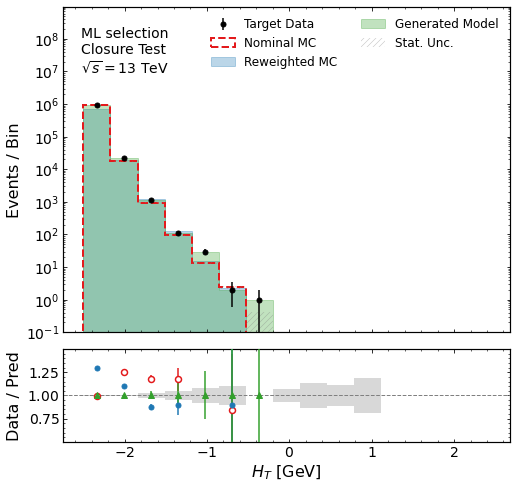

Metrics for met_recalc_pt in Combined_CRs:
  Nominal MC -> chi2/ndf: 4095.67/14 (p=0.0000) | Norm W1: 0.1658
  Reweighted -> chi2/ndf: 9302.86/14 (p=0.0000) | Norm W1: 0.0824
  Generated  -> chi2/ndf: 0.00/14 (p=1.0000) | Norm W1: 0.0000
----------------------------------------------------------------------


/tmp/ipykernel_93099/321456803.py:375: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved Parquet files for Combined_CRs


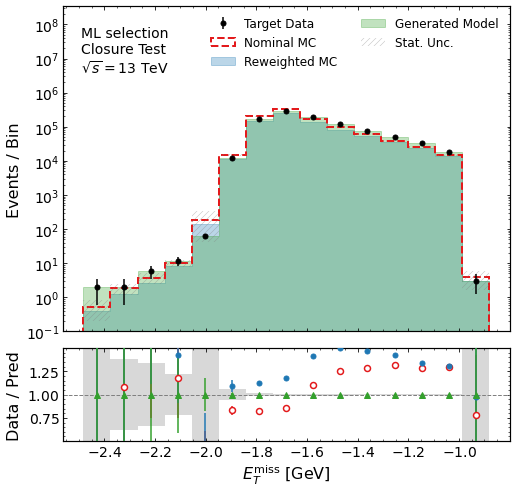

Metrics for mjj in Combined_CRs:
  Nominal MC -> chi2/ndf: 135.77/11 (p=0.0000) | Norm W1: 0.0318
  Reweighted -> chi2/ndf: 3275.79/11 (p=0.0000) | Norm W1: 0.0492
  Generated  -> chi2/ndf: 50.31/8 (p=0.0000) | Norm W1: 0.0082
----------------------------------------------------------------------


/tmp/ipykernel_93099/321456803.py:375: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved Parquet files for Combined_CRs


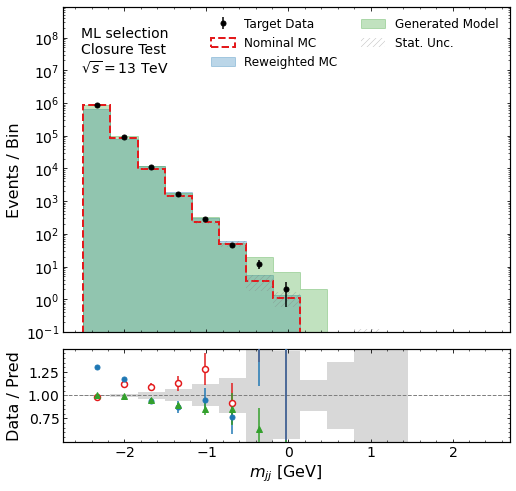

Metrics for ljet1_tau21 in Combined_CRs:
  Nominal MC -> chi2/ndf: 506.67/14 (p=0.0000) | Norm W1: 0.0875
  Reweighted -> chi2/ndf: 3242.66/14 (p=0.0000) | Norm W1: 0.0267
  Generated  -> chi2/ndf: 2061.62/14 (p=0.0000) | Norm W1: 0.0198
----------------------------------------------------------------------


/tmp/ipykernel_93099/321456803.py:375: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved Parquet files for Combined_CRs


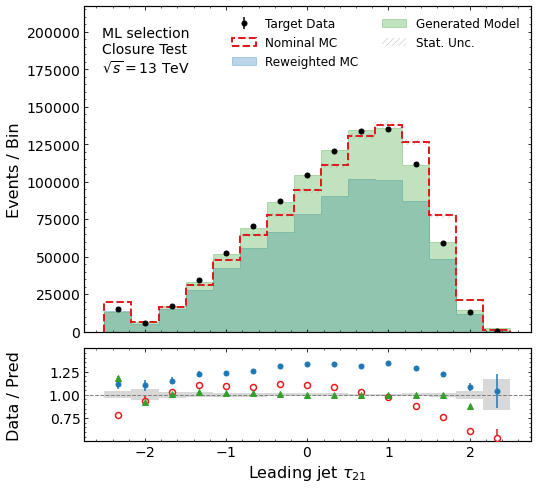

Metrics for ljet1_tau32 in Combined_CRs:
  Nominal MC -> chi2/ndf: 741.65/14 (p=0.0000) | Norm W1: 0.0842
  Reweighted -> chi2/ndf: 3403.19/14 (p=0.0000) | Norm W1: 0.0354
  Generated  -> chi2/ndf: 844.48/14 (p=0.0000) | Norm W1: 0.0111
----------------------------------------------------------------------


/tmp/ipykernel_93099/321456803.py:375: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved Parquet files for Combined_CRs


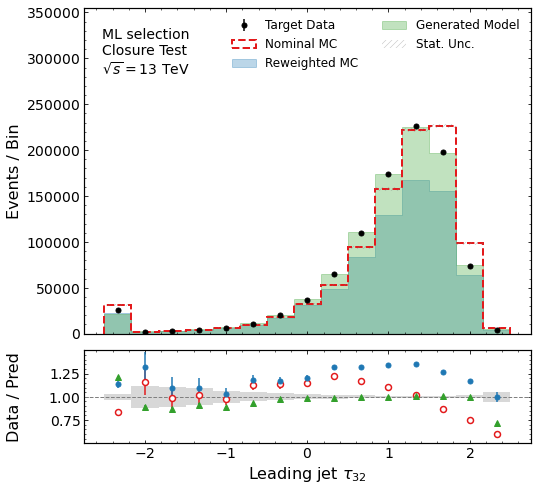

Metrics for ljet2_tau21 in Combined_CRs:
  Nominal MC -> chi2/ndf: 662.27/14 (p=0.0000) | Norm W1: 0.1113
  Reweighted -> chi2/ndf: 3252.77/14 (p=0.0000) | Norm W1: 0.0340
  Generated  -> chi2/ndf: 225.99/14 (p=0.0000) | Norm W1: 0.0060
----------------------------------------------------------------------


/tmp/ipykernel_93099/321456803.py:375: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved Parquet files for Combined_CRs


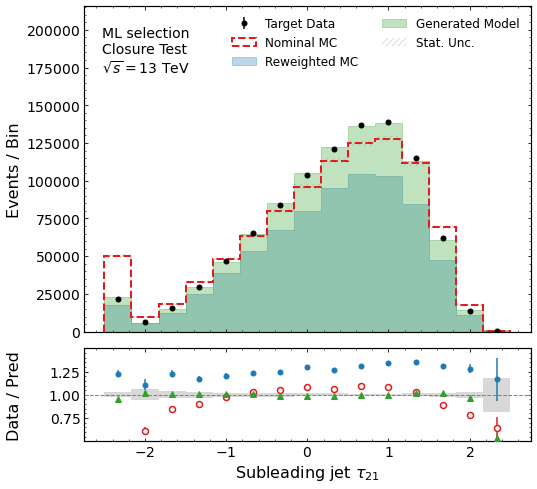

Metrics for ljet2_tau32 in Combined_CRs:
  Nominal MC -> chi2/ndf: 1155.87/14 (p=0.0000) | Norm W1: 0.2113
  Reweighted -> chi2/ndf: 3241.09/14 (p=0.0000) | Norm W1: 0.0095
  Generated  -> chi2/ndf: 138.24/14 (p=0.0000) | Norm W1: 0.0078
----------------------------------------------------------------------


/tmp/ipykernel_93099/321456803.py:375: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved Parquet files for Combined_CRs


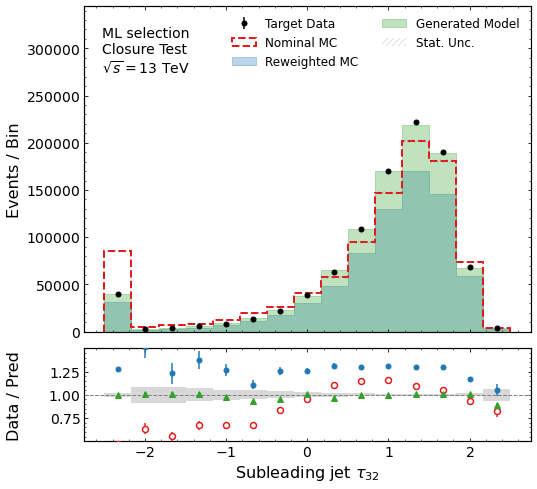

In [5]:
import os
import sys
import torch
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plot_dir = "Closure_Plots"
os.makedirs(plot_dir, exist_ok=True)

regions = ["CR1L", "CR1L1B", "CR2L", "CR0L"]

features = [
    'ht', 'met_recalc_pt', 'mjj', 
    'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]
features_to_generate = [
    'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj'
]

context_vars = [
    'met_recalc_pt', 'ht'
]


device = torch.device("cuda" if False else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------------------
# SELECT YOUR CLOSURE TEST MODE (1, 2, 3, or 4)
# ---------------------------------------------------------------------
EVALUATION_MODE = 4

# Mode 1: Per-region plot using respective trained reweight
# Mode 2: Per-region plot using the COMBINED trained reweight
# Mode 3: Combined plot using weights from ALL separate regions
# Mode 4: Combined plot using the COMBINED trained reweight

# =====================================================================
# 2. HELPER FUNCTIONS
# =====================================================================
def regularize_weights(weights, sigma=3.0):
    mean_w = np.mean(weights)
    std_w = np.std(weights)
    upper_bound = mean_w + (sigma * std_w)
    return np.clip(weights, a_min=0, a_max=upper_bound)

def evaluate_on_the_fly(model, df_mc_pd, feature_list):
    """Passes data through the model and returns the regularized ML weights."""
    x_test_mc = df_mc_pd[feature_list].values
    w_prob = model.evaluation(x_test_mc)
    w_prob = np.clip(w_prob, 1e-7, 1.0 - 1e-7) # Prevent divide-by-zero
    w_cr = (w_prob / (1 - w_prob)).flatten()
    return regularize_weights(w_cr, sigma=3.0)


# def generate_synthetic_data(model, df_target_pd, features, contexts):
#     """Passes context through the Normalizing Flow to generate synthetic features."""
#     # Extract Context
#     c_test = df_target_pd[contexts].values
    
#     # Generate 1 sample per context row
#     # SimpleMAF sample() handles device transfer and numpy conversion internally
#     samples = model.sample(num_samples=1, cond=c_test)
    
#     # Reconstruct a DataFrame with the generated features
#     df_gen_pd = pd.DataFrame(samples, columns=features)
    
#     # Append the context variables back in case we want to plot them
#     for c in contexts:
#         df_gen_pd[c] = df_target_pd[c].values
        
#     # Inherit the exact weights from the target dataset for 1-to-1 comparison
#     weight_col = "final_weight" if "final_weight" in df_target_pd.columns else ("raw_weights" if "raw_weights" in df_target_pd.columns else None)
#     if weight_col:
#         df_gen_pd['weight'] = df_target_pd[weight_col].values
#     else:
#         df_gen_pd['weight'] = 1.0
        
#     return df_gen_pd

def generate_synthetic_data(model, df_target_pd, features, contexts):
    """
    Passes context through the Normalizing Flow to generate synthetic features.
    Includes a clipping step to ensure generated values respect the [-2.5, 2.5] bounds.
    """
    if df_target_pd.shape[0] == 0:
        return pd.DataFrame()
    
    # # 1. Load the model (ens0 is usually the primary model for generation)
    # model_file = os.path.join(model_path, f"{model_prefix}_ens0.pt")
    
    # try:
    #     # Using weights_only=False because SimpleMAF is a custom class
    #     model = torch.load(model_file, map_location=device, weights_only=False)
    #     model.to(device)
    # except Exception as e:
    #     print(f"Error loading generative model {model_file}: {e}")
    #     return pd.DataFrame()

    # 2. Prepare the context (conditional variables)
    # Ensure variables exist in the dataframe
    valid_contexts = [c for c in contexts if c in df_target_pd.columns]
    c_test = df_target_pd[valid_contexts].values
    
    # 3. Sample from the Flow
    # We generate 1 synthetic sample for every 1 real data event
    samples = model.sample(num_samples=1, cond=c_test)
    
    # 4. THE FIX: Clip to the Scaler's range
    # Normalizing Flows use Gaussian bases with infinite tails. 
    # This forces the output to stay within your scaled range of [-2.5, 2.5].
    samples = np.clip(samples, a_min=-2.5, a_max=2.5)
    
    # 5. Reconstruct the DataFrame
    df_gen_pd = pd.DataFrame(samples, columns=features)
    
    # 6. Map context variables back into the dataframe for plotting/consistency
    for c in valid_contexts:
        df_gen_pd[c] = df_target_pd[c].values
        
    # 7. Inherit Weights 
    # This ensures your 'Generated' histogram matches the 'Data' normalization
    weight_col = None
    for col in ['final_weight', 'raw_weights', 'weight']:
        if col in df_target_pd.columns:
            weight_col = col
            break
            
    if weight_col:
        df_gen_pd['weight'] = df_target_pd[weight_col].values
    else:
        df_gen_pd['weight'] = 1.0
        
    return df_gen_pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np
import polars as pl

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np
import polars as pl
from scipy.stats import chi2 as chi2_stat
from scipy.stats import wasserstein_distance

def plot_closure(region_name: str, df_mc: pl.DataFrame, df_gen: pl.DataFrame, df_data: pl.DataFrame, feature: str, force_log: bool = False):
    """
    Combined HEP closure plot comparing Target Data vs:
    1. Nominal MC
    2. ML Reweighted MC
    3. Generated Synthetic Data
    
    Styled to match ATLAS-like data/MC comparisons with stat bands and dynamic bounds.
    """
    
    # Thesis/Publication styling settings
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12,
        'lines.linewidth': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.formatter.use_mathtext': True,
        'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5 # Thinner hatch lines look cleaner
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }
    
    log_variables = ['ht', 'met_recalc_pt', 'met', 'mjj']
    use_log = force_log or any(log_var in feature.lower() for log_var in log_variables)
    
    # Extract arrays
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    gen_arr = df_gen.get_column(feature).drop_nulls().to_numpy()
    
    if len(data_arr) == 0:
        print(f"Skipping {feature} - No valid target data.")
        return
        
    # Extract Weights
    data_weight_col = "final_weight" if "final_weight" in df_data.columns else ("raw_weights" if "raw_weights" in df_data.columns else None)
    data_weights = df_data.get_column(data_weight_col).to_numpy() if data_weight_col else np.ones_like(data_arr)
    
    mc_weight_col = "final_weight" 
    raw_weights_mc = df_mc.get_column(mc_weight_col).to_numpy() if mc_weight_col else np.ones_like(mc_arr)
    ml_weights_mc = df_mc.get_column("ml_extrapolation_weight").to_numpy()
    reweighted_mc_weights = raw_weights_mc * ml_weights_mc
    
    gen_weights = df_gen.get_column("weight").to_numpy() if "weight" in df_gen.columns else np.ones_like(gen_arr)
    
    # Setup Figure (Updated layout and sizes)
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Dynamic binning spanning all distributions (Updated to 15 bins)
    combined_arr = np.concatenate([data_arr, mc_arr, gen_arr])
    bins = np.histogram_bin_edges(combined_arr, bins=15)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    # --- 1. MAIN PANEL ---
    # Nominal MC (Red Step Line)
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights_mc)
    sumw2_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights_mc**2)
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights_mc, histtype='step', 
                 color='#e31a1c', linewidth=2, linestyle='--', label='Nominal MC')
                 
    # Plot Nominal MC Statistical Uncertainty Band
    mc_err = np.sqrt(sumw2_mc_raw)
    ax_main.bar(bin_centers, 2 * mc_err, bottom=counts_mc_raw - mc_err, width=bin_widths,
                color='none', edgecolor='gray', hatch='////', linewidth=0,
                alpha=0.5, zorder=5, label='Stat. Unc.')
    
    # ML Reweighted MC (Blue Filled)
    counts_mc_ml, _ = np.histogram(mc_arr, bins=bins, weights=reweighted_mc_weights)
    sumw2_mc_ml, _ = np.histogram(mc_arr, bins=bins, weights=reweighted_mc_weights**2)
    ax_main.hist(mc_arr, bins=bins, weights=reweighted_mc_weights, histtype='stepfilled', 
                 color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label='Reweighted MC')
                 
    # Generated Model (Green Filled/Step)
    counts_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights)
    sumw2_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights**2)
    ax_main.hist(gen_arr, bins=bins, weights=gen_weights, histtype='stepfilled', 
                 color='#33a02c', alpha=0.3, edgecolor='#33a02c', label='Generated Model')

    # Target Data (Black Points)
    counts_data, _ = np.histogram(data_arr, bins=bins, weights=data_weights)
    sumw2_data, _ = np.histogram(data_arr, bins=bins, weights=data_weights**2)
    data_errors = np.sqrt(sumw2_data)
    
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, 
                     fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)
    
    # --- METRICS CALCULATION ---
    std_data = np.std(data_arr) if len(data_arr) > 0 else 1.0
    c_data_clean = np.clip(counts_data, 0, None)
    
    # Wasserstein Distances
    w1_nom = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_mc_raw, 0, None)) / std_data
    w1_rw  = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_mc_ml, 0, None)) / std_data
    w1_gen = wasserstein_distance(bin_centers, bin_centers, u_weights=c_data_clean, v_weights=np.clip(counts_gen, 0, None)) / std_data

    def get_chi2_pval(c_target, c_pred, s2_target, s2_pred):
        mask = (c_target > 0) | (c_pred > 0)
        tot_var = s2_target[mask] + s2_pred[mask]
        valid = tot_var > 0
        chi2_val = np.sum((c_target[mask][valid] - c_pred[mask][valid])**2 / tot_var[valid])
        ndf = np.sum(valid) - 1 
        if ndf < 1: ndf = 1
        p_val = chi2_stat.sf(chi2_val, ndf)
        return chi2_val, ndf, p_val

    chi2_nom, ndf_nom, p_nom = get_chi2_pval(counts_data, counts_mc_raw, sumw2_data, sumw2_mc_raw)
    chi2_rw, ndf_rw, p_rw = get_chi2_pval(counts_data, counts_mc_ml, sumw2_data, sumw2_mc_ml)
    chi2_gen, ndf_gen, p_gen = get_chi2_pval(counts_data, counts_gen, sumw2_data, sumw2_gen)

    print(f"Metrics for {feature} in {region_name}:")
    print(f"  Nominal MC -> chi2/ndf: {chi2_nom:.2f}/{ndf_nom} (p={p_nom:.4f}) | Norm W1: {w1_nom:.4f}")
    print(f"  Reweighted -> chi2/ndf: {chi2_rw:.2f}/{ndf_rw} (p={p_rw:.4f}) | Norm W1: {w1_rw:.4f}")
    print(f"  Generated  -> chi2/ndf: {chi2_gen:.2f}/{ndf_gen} (p={p_gen:.4f}) | Norm W1: {w1_gen:.4f}")
    print("-" * 70)

    # --- DYNAMIC Y-AXIS SCALING ---
    max_counts = max(
        np.max(counts_data) + np.max(data_errors) if len(counts_data) > 0 else 0,
        np.max(counts_mc_raw + mc_err) if len(counts_mc_raw) > 0 else 0,
        np.max(counts_mc_ml) if len(counts_mc_ml) > 0 else 0,
        np.max(counts_gen) if len(counts_gen) > 0 else 0
    )
    
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, max_counts * 1000) # Updated matching multiplier
    else:
        ax_main.set_ylim(0, max_counts * 1.55)
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    # Updated textstr to match design
    
    textstr = f"{selection} selection\n"+"Closure Test\n" + r"$\sqrt{s} = 13$ TeV"
        
    ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                 
    # Custom Legend Formatting
    handles, loc_labels = ax_main.get_legend_handles_labels()
    if "Target Data" in loc_labels:
        idx = loc_labels.index("Target Data")
        handles.insert(0, handles.pop(idx))
        loc_labels.insert(0, loc_labels.pop(idx))
    ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2) # Updated to ncol=2
    
    # --- 2. RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        # Ratios
        ratio_raw = counts_data / counts_mc_raw
        ratio_rw  = counts_data / counts_mc_ml
        ratio_gen = counts_data / counts_gen
        
        # Error propagation (Data / Pred) 
        rel_err_data = np.where(counts_data > 0, data_errors / counts_data, 0) 
         
        # Fractional Nominal MC Error
        rel_err_raw = np.where(counts_mc_raw > 0, np.sqrt(sumw2_mc_raw) / counts_mc_raw, 0) 
        ratio_raw_err = np.abs(ratio_raw) * np.sqrt(rel_err_data**2 + rel_err_raw**2) 
         
        rel_err_rw = np.where(counts_mc_ml > 0, np.sqrt(sumw2_mc_ml) / counts_mc_ml, 0) 
        ratio_rw_err = np.abs(ratio_rw) * np.sqrt(rel_err_data**2 + rel_err_rw**2) 
         
        rel_err_gen = np.where(counts_gen > 0, np.sqrt(sumw2_gen) / counts_gen, 0) 
        ratio_gen_err = np.abs(ratio_gen) * np.sqrt(rel_err_data**2 + rel_err_gen**2)

        # Mask invalid values
        ratio_raw = np.where(counts_mc_raw > 0, ratio_raw, np.nan)
        ratio_rw = np.where(counts_mc_ml > 0, ratio_rw, np.nan)
        ratio_gen = np.where(counts_gen > 0, ratio_gen, np.nan)

    # Plot Nominal MC Stat Uncertainty band around 1.0 in ratio panel
    ax_ratio.bar(bin_centers, 2 * rel_err_raw, bottom=1.0 - rel_err_raw, width=bin_widths,
                 color='gray', hatch='////', edgecolor='none', alpha=0.3, zorder=1)

    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, zorder=2)
    
    # Plot Nominal Ratio (Red Open Circles)
    ax_ratio.errorbar(bin_centers, ratio_raw, yerr=ratio_raw_err, fmt='o', 
                      color='#e31a1c', markerfacecolor='white', markeredgewidth=1.5, capsize=0, markersize=6, zorder=10)
                      
    # Plot ML Reweighted Ratio (Blue Filled Circles)
    ax_ratio.errorbar(bin_centers, ratio_rw, yerr=ratio_rw_err, fmt='o', 
                      color='#1f78b4', capsize=0, markersize=5, zorder=10)
                      
    # Plot Generated Ratio (Green Filled Triangles)
    ax_ratio.errorbar(bin_centers, ratio_gen, yerr=ratio_gen_err, fmt='^', 
                      color='#33a02c', capsize=0, markersize=6, zorder=10)
    
    x_label = pretty_labels.get(feature, feature)
    
    ax_ratio.set_xlabel(x_label)
    ax_ratio.set_ylabel("Data / Pred")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_yticks([0.75, 1.0, 1.25])
    
    ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    # Reduced ncol on ratio to prevent clipping if handles get long
    ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)
    
    fig.align_ylabels((ax_main, ax_ratio))
    
    # --- 3. SAVE AND CLOSE ---
    save_name = f"Closure_{feature}_{selection}.pdf"
    
    plt.savefig(f"Closure_Plots/{save_name}", bbox_inches='tight', format='pdf')

    # --- 4. SAVE EVENTS TO PARQUET ---
    # Add the combined weight to MC before saving so you don't have to recalculate it later
    df_mc_to_save = df_mc.with_columns(
        (pl.col("final_weight") * pl.col("ml_extrapolation_weight")).alias("reweighted_weight")
    )
    
    # Save the full dataframes. 
    # Using region_name ensures you don't overwrite files if analyzing multiple regions
    df_mc_to_save.write_parquet(f"AD_Events/CR_events_mc_{selection}.parquet")
    df_data.write_parquet(f"AD_Events/CR_events_data_{selection}.parquet")
    df_gen.write_parquet(f"AD_Events/CR_events_gen_{selection}.parquet")
    
    print(f"Saved Parquet files for {region_name}")

    # Show the plot so you can see the distribution, then close
    plt.show()
    plt.close(fig)
# =====================================================================
# 3. EXECUTION LOGIC BASED ON MODE
# =====================================================================
print("="*60)
print(f" 🔬 INITIATING CLOSURE TESTS (MODE {EVALUATION_MODE})")
print("="*60)

if EVALUATION_MODE == 1:
    print("Mode 1: Per-region closure using separate models.")
    for region in regions:
        try:
            # Load Data
            df_mc_pd = pl.read_parquet(f"{dataset_path}/{region}/MC_{region}_test.parquet").to_pandas()
            df_data = pl.read_parquet(f"{dataset_path}/{region}/DATA_{region}_test.parquet")
            
            # Load specific model
            model_file = os.path.join(model_path, f"reweight_{region}_ens0.pt")
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            
            # Evaluate & Append
            df_mc_pd['ml_extrapolation_weight'] = evaluate_on_the_fly(model, df_mc_pd, features)
            df_mc = pl.from_pandas(df_mc_pd)
            
            print(f"\nPlotting {region}...")
            for feature in features:
                plot_closure(region, df_mc, df_data, feature)
        except Exception as e:
            print(f"Skipping {region}: {e}")

elif EVALUATION_MODE == 2:
    print("Mode 2: Per-region closure using the COMBINED model.")
    try:
        model_file = os.path.join(model_path, "reweight_Combined_CRs_ens0.pt")
        combined_model = torch.load(model_file, map_location=device, weights_only=False)
        combined_model.to(device)
        print(f"Successfully loaded Combined Model.")
    except Exception as e:
        print(f"Failed to load Combined Model. Error: {e}")
        sys.exit()

    for region in regions:
        try:
            # Load raw test data
            df_mc_pd = pl.read_parquet(f"{dataset_path}/{region}/MC_{region}_test.parquet").to_pandas()
            df_data = pl.read_parquet(f"{dataset_path}/{region}/DATA_{region}_test.parquet")
            
            # Evaluate on the fly using Combined Model
            df_mc_pd['ml_extrapolation_weight'] = evaluate_on_the_fly(combined_model, df_mc_pd, features)
            df_mc = pl.from_pandas(df_mc_pd)
            
            print(f"\nPlotting {region} (Evaluated via Combined Model)...")
            for feature in features:
                plot_closure(f"{region}_via_CombinedModel", df_mc, df_data, feature)
        except Exception as e:
            print(f"Skipping {region}: {e}")

elif EVALUATION_MODE == 3:
    print("Mode 3: Combined plot using separate region weights.")
    mc_dfs = []
    data_dfs = []
    
    for region in regions:
        try:
            # Load Data
            df_mc_pd = pl.read_parquet(f"{dataset_path}/{region}/MC_{region}_test.parquet").to_pandas()
            df_data = pl.read_parquet(f"{dataset_path}/{region}/DATA_{region}_test.parquet")
            
            # Load specific model & Evaluate
            model_file = os.path.join(model_path, f"reweight_{region}_ens0.pt")
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            
            df_mc_pd['ml_extrapolation_weight'] = evaluate_on_the_fly(model, df_mc_pd, features)
            
            mc_dfs.append(pl.from_pandas(df_mc_pd))
            data_dfs.append(df_data)
        except Exception as e:
            print(f"Skipping {region} from combination: {e}")
            
    if mc_dfs and data_dfs:
        df_mc_all = pl.concat(mc_dfs)
        df_data_all = pl.concat(data_dfs)
        print("\nPlotting Combined Dataset (Using Separate Models)...")
        for feature in features:
            plot_closure("All_Regions_SeparateModels", df_mc_all, df_data_all, feature)
    else:
        print("No datasets found to combine.")

elif EVALUATION_MODE == 4:
    print("Mode 4: Combined plot using the COMBINED model.")
    run_name = "Combined_CRs"
    try:
        # Load the combined model
        model_file_rw = os.path.join(model_path, f"reweight_{run_name}_ens0.pt")
        model_file_gen = os.path.join(model_path, f"generate_{run_name}_ens0.pt")
        
        combined_model_rw = torch.load(model_file_rw, map_location=device, weights_only=False)
        combined_model_rw.to(device)
        combined_model_gen = torch.load(model_file_gen, map_location=device, weights_only=False)
        combined_model_gen.to(device)
        print(f"Successfully loaded Combined Models for Reweighting and Generation.")

        # Load the massive combined test sets
        df_mc_pd = pl.read_parquet(f"{dataset_path}/{run_name}/MC_{run_name}_test.parquet").to_pandas()
        df_data = pl.read_parquet(f"{dataset_path}/{run_name}/DATA_{run_name}_test.parquet").to_pandas()
        df_gen_pd = generate_synthetic_data(combined_model_gen, df_data, features_to_generate, context_vars)
        
        # Evaluate
        df_mc_pd['ml_extrapolation_weight'] = evaluate_on_the_fly(combined_model_rw, df_mc_pd, features)
        df_mc = pl.from_pandas(df_mc_pd)
        df_data = pl.from_pandas(df_data)
        df_gen = pl.from_pandas(df_gen_pd)
        
        print(f"\nPlotting {run_name} (Using Combined Model)...")
        for feature in features:
            # plot_closure(run_name, df_mc, df_data, feature)
            plot_closure(run_name, df_mc, df_gen, df_data, feature)
    except Exception as e:
        print(f"Failed to load datasets/models for Mode 4. Error: {e}")

else:
    print("Invalid EVALUATION_MODE. Please select 1, 2, 3, or 4.")

In [4]:
# import os
# import sys
# import torch
# import numpy as np
# import polars as pl
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# target_region = "SR_clean"         

# plot_dir = "SR_Extrapolation_Plots"
# os.makedirs(plot_dir, exist_ok=True)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# features_to_evaluate = [
#     'met_recalc_pt', 'ht', 
#     'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
# ]

# # ---------------------------------------------------------------------
# # SELECT YOUR EXTRAPOLATION MODE (1, 2, or 3)
# # ---------------------------------------------------------------------
# EXTRAPOLATION_MODE = 2

# # Mode 1: Combine (multiply) the weights from all individual CR models
# # Mode 2: Use the weights from the single 'Combined_CRs' model
# # Mode 3: Apply specific CR models to specific background processes

# N_ENSEMBLES = 1
# DENSITY_PLOT = False
# # Process Mapping for Mode 3
# PROCESS_MAPPING = {
#     'Wjets': 'CR1L',
#     'ttbar': 'CR1L1B',
#     'Single_top': 'CR1L1B',
#     'Zjets': 'CR2L',
#     'Multijet': 'CR0L',
#     'Diboson': 'CR0L' # Defaulting rare backgrounds to the nominal 0L region
# }

# # =====================================================================
# # 2. HELPER & PLOTTING FUNCTIONS
# # =====================================================================
# def regularize_weights(weights, sigma=3.0):
#     """Caps extreme weight hallucinations at 3-sigma above the mean."""
#     if len(weights) == 0: return weights
#     mean_w = np.mean(weights)
#     std_w = np.std(weights)
#     upper_bound = mean_w + (sigma * std_w)
#     return np.clip(weights, a_min=0, a_max=upper_bound)

# def run_ensemble_inference(model_prefix, n_ensembles, x_data):
#     """Loads ensemble models, averages probabilities, and returns ML weights."""
#     if x_data.shape[0] == 0: return np.array([])
        
#     accumulated_probs = np.zeros((x_data.shape[0], 1))
#     successful_models = 0
    
#     for i in range(n_ensembles):
#         model_file = os.path.join(model_path, f"{model_prefix}_ens{i}.pt")
#         try:
#             model = torch.load(model_file, map_location=device, weights_only=False)
#             model.to(device)
#             w_prob = model.evaluation(x_data)
#             accumulated_probs += w_prob
#             successful_models += 1
#         except Exception as e:
#             print(f"    [!] Failed to load {model_file}: {e}")
            
#     if successful_models == 0:
#         raise RuntimeError(f"No models found for prefix: {model_prefix}")
        
#     avg_prob = accumulated_probs / successful_models
#     avg_prob = np.clip(avg_prob, 1e-7, 1.0 - 1e-7)
#     w_ml = (avg_prob / (1 - avg_prob)).flatten()
    
#     return regularize_weights(w_ml, sigma=3.0)

# import os
# import numpy as np
# import polars as pl
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import matplotlib.ticker as ticker
# from scipy.stats import chi2 as chi2_stat
# from scipy.stats import wasserstein_distance

# def plot_sr_extrapolation(mode_label: str, df_mc: pl.DataFrame, df_data: pl.DataFrame, feature: str, force_log: bool = False):
#     """
#     Plots Extrapolated Background vs Observed Data in the Signal Region.
#     Applies publication-grade styling, dynamic binning, and calculates validation metrics.
#     """
    
#     # Thesis/Publication styling settings
#     plt.rcParams.update({
#         'font.size': 14,
#         'axes.labelsize': 16,
#         'xtick.labelsize': 14,
#         'ytick.labelsize': 14,
#         'legend.fontsize': 12,
#         'lines.linewidth': 1.5,
#         'xtick.direction': 'in',
#         'ytick.direction': 'in',
#         'xtick.top': True,
#         'ytick.right': True,
#         'axes.formatter.use_mathtext': True,
#         'axes.linewidth': 1.2
#     })
    
#     # Mapping for publication-ready axis labels
#     pretty_labels = {
#         'ht': r'$H_{T}$ [GeV]',
#         'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
#         'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
#         'mjj': r'$m_{jj}$ [GeV]',
#         'ljet1_tau21': r'Leading jet $\tau_{21}$',
#         'ljet1_tau32': r'Leading jet $\tau_{32}$',
#         'ljet2_tau21': r'Subleading jet $\tau_{21}$',
#         'ljet2_tau32': r'Subleading jet $\tau_{32}$'
#     }
    
#     log_variables = ['ht', 'met_recalc_pt', 'met']
#     use_log = force_log or any(log_var in feature.lower() for log_var in log_variables)
    
#     data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
#     mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    
#     if len(data_arr) == 0 and len(mc_arr) == 0:
#         print(f"Skipping {feature} - No valid data.")
#         return
        
#     base_weight_col = "final_weight" if "final_weight" in df_mc.columns else "raw_weights"
#     raw_weights = df_mc.get_column(base_weight_col).to_numpy()
#     extrapolated_weights = df_mc.get_column("extrapolated_SR_weight").to_numpy()
    
#     fig = plt.figure(figsize=(8, 8))
#     gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    
#     ax_main = fig.add_subplot(gs[0])
#     ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
#     # Dynamic binning
#     combined_arr = np.concatenate([data_arr, mc_arr])
#     bins = np.histogram_bin_edges(combined_arr, bins=15)
#     bin_centers = (bins[:-1] + bins[1:]) / 2

#     # --- 1. MAIN PANEL ---
#     # Nominal MC (Red Step Line)
#     counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights)
#     sumw2_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights**2)
#     ax_main.hist(mc_arr, bins=bins, weights=raw_weights, histtype='step', 
#                  color='#e31a1c', linewidth=2, linestyle='--', label='Nominal MC (Uncorrected)')
    
#     # Extrapolated Background (Blue Filled)
#     counts_mc_extrap, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights)
#     sumw2_extrap, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights**2)
#     ax_main.hist(mc_arr, bins=bins, weights=extrapolated_weights, histtype='stepfilled', 
#                  color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label=f'Extrap. Bkg')
    
#     # Target Data (Black Points)
#     counts_data, _ = np.histogram(data_arr, bins=bins)
#     data_errors = np.sqrt(counts_data)
#     ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, 
#                      fmt='ko', label='Observed Data', zorder=10, capsize=0, markersize=5)
    
#     # =================================================================
#     # --- METRICS CALCULATION & CONSOLE PRINT ---
#     # =================================================================
#     std_data = np.std(data_arr) if len(data_arr) > 0 else 1.0
    
#     # Floor any net-negative bins to 0 (SciPy requires non-negative measures)
#     c_mc_raw_clean = np.clip(counts_mc_raw, 0, None)
#     c_mc_extrap_clean = np.clip(counts_mc_extrap, 0, None)
    
#     w1_nom = wasserstein_distance(bin_centers, bin_centers, 
#                                   u_weights=counts_data, v_weights=c_mc_raw_clean) / std_data
#     w1_extrap = wasserstein_distance(bin_centers, bin_centers, 
#                                      u_weights=counts_data, v_weights=c_mc_extrap_clean) / std_data

#     def get_chi2_pval(c_data, c_mc, s2_mc):
#         mask = (c_data > 0) | (c_mc > 0)
#         tot_var = c_data[mask] + s2_mc[mask]
#         valid = tot_var > 0
#         chi2_val = np.sum((c_data[mask][valid] - c_mc[mask][valid])**2 / tot_var[valid])
#         ndf = np.sum(valid) - 1 
#         if ndf < 1: ndf = 1
#         p_val = chi2_stat.sf(chi2_val, ndf)
#         return chi2_val, ndf, p_val

#     chi2_nom, ndf_nom, p_nom = get_chi2_pval(counts_data, counts_mc_raw, sumw2_raw)
#     chi2_extrap, ndf_extrap, p_extrap = get_chi2_pval(counts_data, counts_mc_extrap, sumw2_extrap)

#     print(f"Metrics for {feature} Extrapolation ({mode_label}):")
#     print(f"  Nominal      -> chi2/ndf: {chi2_nom:.2f}/{ndf_nom} (p={p_nom:.4f}) | Norm W1: {w1_nom:.4f}")
#     print(f"  Extrapolated -> chi2/ndf: {chi2_extrap:.2f}/{ndf_extrap} (p={p_extrap:.4f}) | Norm W1: {w1_extrap:.4f}")
#     print("-" * 60)
#     # =================================================================

#     # --- DYNAMIC Y-AXIS SCALING (Linear vs Log) ---
#     max_data = np.max(counts_data) + np.max(data_errors) if len(counts_data) > 0 else 0
#     max_mc = max(np.max(counts_mc_raw), np.max(counts_mc_extrap)) if len(counts_mc_raw) > 0 else 0
#     y_max = max(max_data, max_mc)
    
#     if use_log:
#         ax_main.set_yscale('log')
#         ax_main.set_ylim(0.1, y_max * 100) # 100x headroom for log plots
#     else:
#         ax_main.set_ylim(0, y_max * 1.65)  # 1.65x headroom for linear plots
#         ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
#     ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    
#     # Main Panel Aesthetics
#     ax_main.set_ylabel("Events / Bin")
#     plt.setp(ax_main.get_xticklabels(), visible=False)
    
#     # Add Region/Metadata Text
#     textstr = (
#         r"$\mathbf{SR\ Extrapolation}$" + "\n" + 
#         r"$\sqrt{s} = 13$ TeV" + "\n" 
#         # rf"Nom $\chi^2/ndf$: {chi2_nom:.1f}/{ndf_nom} | $W_1$: {w1_nom:.2f}" + "\n" +
#         # rf"ML $\chi^2/ndf$: {chi2_extrap:.1f}/{ndf_extrap} | $W_1$: {w1_extrap:.2f}"
#     )
#     ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes,
#                  fontsize=12, verticalalignment='top')
                 
#     # Custom Legend Formatting (Force Data to be first)
#     handles, loc_labels = ax_main.get_legend_handles_labels()
#     if "Observed Data" in loc_labels:
#         data_idx = loc_labels.index("Observed Data")
#         handles.insert(0, handles.pop(data_idx))
#         loc_labels.insert(0, loc_labels.pop(data_idx))
        
#     ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=1)
    
#     # --- 2. RATIO PANEL ---
#     with np.errstate(divide='ignore', invalid='ignore'):
#         ratio_raw = counts_data / counts_mc_raw
#         ratio_raw_err = data_errors / counts_mc_raw
#         ratio_extrap = counts_data / counts_mc_extrap
#         ratio_extrap_err = data_errors / counts_mc_extrap
        
#         ratio_raw = np.where(counts_mc_raw > 0, ratio_raw, np.nan)
#         ratio_extrap = np.where(counts_mc_extrap > 0, ratio_extrap, np.nan)
#         ratio_raw_err = np.where(counts_mc_raw > 0, ratio_raw_err, np.nan)
#         ratio_extrap_err = np.where(counts_mc_extrap > 0, ratio_extrap_err, np.nan)

#     ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
    
#     # Plot Nominal Ratio (Open Circles)
#     ax_ratio.errorbar(bin_centers, ratio_raw, yerr=ratio_raw_err, fmt='o', 
#                       color='#e31a1c', markerfacecolor='white', markeredgewidth=1.5, capsize=0, markersize=6)
                      
#     # Plot Extrapolated Ratio (Filled Circles)
#     ax_ratio.errorbar(bin_centers, ratio_extrap, yerr=ratio_extrap_err, fmt='o', 
#                       color='#1f78b4', capsize=0, markersize=5)
    
#     x_label = pretty_labels.get(feature, feature)
    
#     # Ratio Panel Aesthetics
#     ax_ratio.set_xlabel(x_label)
#     ax_ratio.set_ylabel("Data / Bkg")
#     ax_ratio.set_ylim(0.5, 1.5)
#     ax_ratio.set_yticks([0.75, 1.0, 1.25])
    
#     ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
#     ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
#     # ax_ratio.legend(['Data / Nominal', 'Data / Extrapolated'], loc='upper right', fontsize=10, frameon=False, ncol=2)
    
#     fig.align_ylabels((ax_main, ax_ratio))
    
#     # --- 3. SAVE AND CLOSE ---
#     os.makedirs("Extrapolation_Plots", exist_ok=True)
#     save_name = f"Extrapolation_Plots/SR_{mode_label}_{feature}.pdf"
#     plt.savefig(save_name, bbox_inches='tight', format='pdf')
#     print(f"Saved extrapolation plot: {save_name}")
    
#     plt.show()
#     plt.close(fig)

# # =====================================================================
# # 3. LOAD DATASETS
# # =====================================================================
# print(f"\nLoading scaled Signal Region datasets ({target_region})...")
# mc_sr_path = f"{dataset_path}/MC_{target_region}.parquet"
# data_sr_path = f"{dataset_path}/DATA_{target_region}.parquet"

# try:
#     df_mc_sr = pl.read_parquet(mc_sr_path).to_pandas()
#     df_data_sr = pl.read_parquet(data_sr_path) # Keep data as polars for plotting
#     x_sr_mc = df_mc_sr[features_to_evaluate].values
#     print(f"Loaded {df_mc_sr.shape[0]} MC events and {df_data_sr.height} Data events.")
# except FileNotFoundError as e:
#     print(f"Error: {e}")
#     sys.exit(1)

# weight_col = 'final_weight'

# # =====================================================================
# # 4. EXTRAPOLATION LOGIC
# # =====================================================================
# print("\n" + "="*70)
# print(f" 🚀 INITIATING SR EXTRAPOLATION & PLOTTING (MODE {EXTRAPOLATION_MODE})")
# print("="*70)

# mode_label = f"Mode {EXTRAPOLATION_MODE}"

# if EXTRAPOLATION_MODE == 1:
#     print("Mode 1: Combining (multiplying) weights from all separate CR models.")
#     regions = ["CR1L", "CR1L1B", "CR2L", "CR0L"]
#     df_mc_sr['ml_extrapolation_weight'] = 1.0
    
#     for region in regions:
#         print(f" -> Applying corrections from {region}...")
#         try:
#             ml_weights = run_ensemble_inference(f"reweight_{region}", N_ENSEMBLES, x_sr_mc)
#             df_mc_sr['ml_extrapolation_weight'] *= ml_weights 
#         except RuntimeError as e:
#             print(f"    [Skipping] {region}: {e}")
            
#     df_mc_sr['ml_extrapolation_weight'] = regularize_weights(df_mc_sr['ml_extrapolation_weight'].values, sigma=3.0)
#     mode_label = "Multiplied CRs"

# elif EXTRAPOLATION_MODE == 2:
#     print("Mode 2: Extrapolating using the single 'Combined_CRs' model.")
#     try:
#         ml_weights = run_ensemble_inference("reweight_Combined_CRs", N_ENSEMBLES, x_sr_mc)
#         df_mc_sr['ml_extrapolation_weight'] = ml_weights
#         mode_label = "Global Combined Model"
#     except RuntimeError as e:
#         print(f"Failed to run Combined model: {e}")
#         sys.exit(1)

# elif EXTRAPOLATION_MODE == 3:
#     print("Mode 3: Process-Specific Component Extrapolation.")
#     df_mc_sr['ml_extrapolation_weight'] = 1.0
#     unique_processes = df_mc_sr['mc_process'].unique()
    
#     for proc in unique_processes:
#         target_cr = PROCESS_MAPPING.get(proc, 'CR0L')
#         print(f" -> Process: {proc:<12} | Assigned Model: {target_cr}")
        
#         mask = df_mc_sr['mc_process'] == proc
#         x_proc = df_mc_sr.loc[mask, features_to_evaluate].values
        
#         if x_proc.shape[0] > 0:
#             try:
#                 ml_weights = run_ensemble_inference(f"reweight_{target_cr}", N_ENSEMBLES, x_proc)
#                 df_mc_sr.loc[mask, 'ml_extrapolation_weight'] = ml_weights
#             except RuntimeError as e:
#                 print(f"    [!] Failed to evaluate {proc}: {e}")
                
#     mode_label = "Process-Mapped"

# else:
#     print("Invalid EXTRAPOLATION_MODE. Please select 1, 2, or 3.")
#     sys.exit(1)

# # =====================================================================
# # 5. CALCULATE FINAL WEIGHTS, SAVE, AND PLOT
# # =====================================================================
# print("\nFinalizing datasets and generating plots...")

# # Calculate the final physics weight
# df_mc_sr['extrapolated_SR_weight'] = df_mc_sr[weight_col] * df_mc_sr['ml_extrapolation_weight']

# # Convert back to Polars for saving and plotting
# df_mc_sr_polars = pl.from_pandas(df_mc_sr)

# # Setup output directory
# output_dir = os.path.join(dataset_path, "SR_Extrapolations")
# os.makedirs(output_dir, exist_ok=True)
# output_path = os.path.join(output_dir, f"MC_{target_region}_extrapolated_Mode{EXTRAPOLATION_MODE}.parquet")

# # Save as Parquet
# df_mc_sr_polars.write_parquet(output_path)
# print(f"✅ Extrapolated Dataset Saved: {output_path}")
# print(f"📊 Global ML Weight Stats -> Min: {df_mc_sr['ml_extrapolation_weight'].min():.4f} | Max: {df_mc_sr['ml_extrapolation_weight'].max():.4f} | Mean: {df_mc_sr['ml_extrapolation_weight'].mean():.4f}")

# # Generate Plots
# print(f"\nGenerating SR inspection plots for Mode {EXTRAPOLATION_MODE}...")
# for feature in features_to_evaluate:
#     plot_sr_extrapolation(mode_label, df_mc_sr_polars, df_data_sr, feature)

# print("\n🎉 Extrapolation and Plotting phase complete! Check the 'SR_Extrapolation_Plots' folder.")

Using device: cpu

Loading scaled Signal Region datasets (SR_clean)...
Loaded 528846 MC events and 188757 Data events.

 🚀 INITIATING SR EXTRAPOLATION & PLOTTING (MODE 2)
Mode 2: Extrapolating using the single 'Combined_CRs' model.

----------------------------------------------------------------------
 🧬 GENERATING SYNTHETIC BACKGROUND FROM SR DATA
----------------------------------------------------------------------
Models_Extrapolation_ML/generate_Combined_CRs_ens0.pt
✅ Generated synthetic features for 528846 events.

Finalizing datasets and generating plots...
✅ Extrapolated Dataset Saved: Final_Dataset_ML/SR_Extrapolations/MC_SR_clean_extrapolated_Mode2.parquet

Generating SR inspection plots for Mode 2...
Metrics for met_recalc_pt Extrapolation (Global Combined Model):
  Nominal      -> chi2/ndf: 50.20/14 (p=0.0000) | Norm W1: 0.0044
  Extrapolated -> chi2/ndf: 4195.07/14 (p=0.0000) | Norm W1: 0.0805
  Generated    -> chi2/ndf: 50.20/14 (p=0.0000) | Norm W1: 0.0044
-------------

/tmp/ipykernel_48362/38619054.py:276: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved extrapolation plot: Extrapolation_Plots/SR_ML_met_recalc_pt.pdf
Saved SR Parquet events to AD_Events/


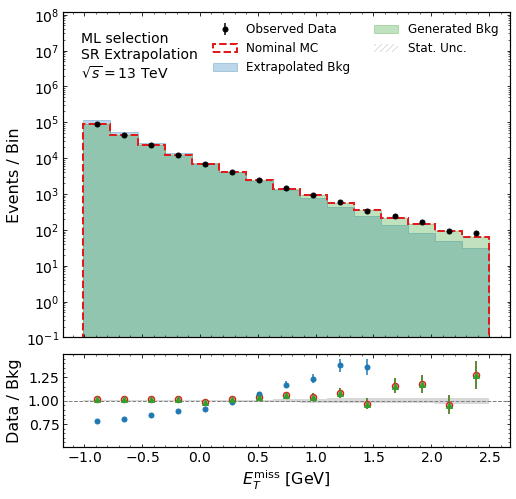

Metrics for ht Extrapolation (Global Combined Model):
  Nominal      -> chi2/ndf: 52.09/14 (p=0.0000) | Norm W1: 0.0052
  Extrapolated -> chi2/ndf: 3754.84/14 (p=0.0000) | Norm W1: 0.0561
  Generated    -> chi2/ndf: 52.09/14 (p=0.0000) | Norm W1: 0.0052
------------------------------------------------------------


/tmp/ipykernel_48362/38619054.py:276: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved extrapolation plot: Extrapolation_Plots/SR_ML_ht.pdf
Saved SR Parquet events to AD_Events/


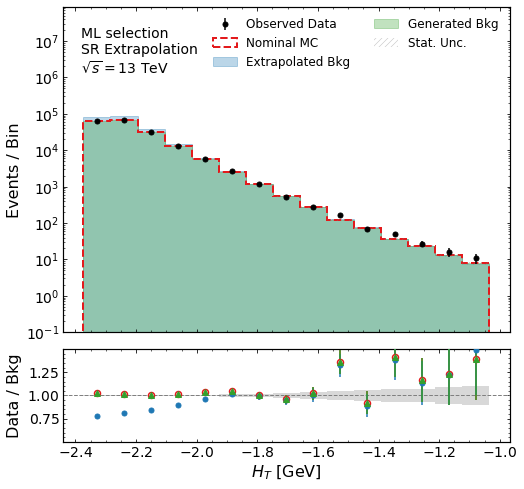

Metrics for mjj Extrapolation (Global Combined Model):
  Nominal      -> chi2/ndf: 307.50/9 (p=0.0000) | Norm W1: 0.0546
  Extrapolated -> chi2/ndf: 3623.62/9 (p=0.0000) | Norm W1: 0.0057
  Generated    -> chi2/ndf: 355164.15/14 (p=0.0000) | Norm W1: 14.0450
------------------------------------------------------------


/tmp/ipykernel_48362/38619054.py:276: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved extrapolation plot: Extrapolation_Plots/SR_ML_mjj.pdf
Saved SR Parquet events to AD_Events/


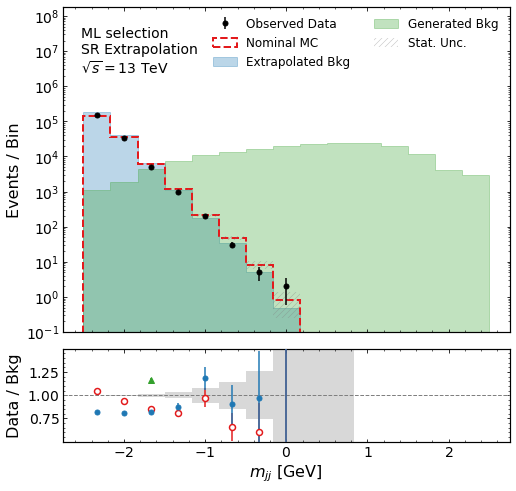

Metrics for ljet1_tau21 Extrapolation (Global Combined Model):
  Nominal      -> chi2/ndf: 749.00/14 (p=0.0000) | Norm W1: 0.0553
  Extrapolated -> chi2/ndf: 3732.94/14 (p=0.0000) | Norm W1: 0.0185
  Generated    -> chi2/ndf: 110090.91/14 (p=0.0000) | Norm W1: 1.0263
------------------------------------------------------------


/tmp/ipykernel_48362/38619054.py:276: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved extrapolation plot: Extrapolation_Plots/SR_ML_ljet1_tau21.pdf
Saved SR Parquet events to AD_Events/


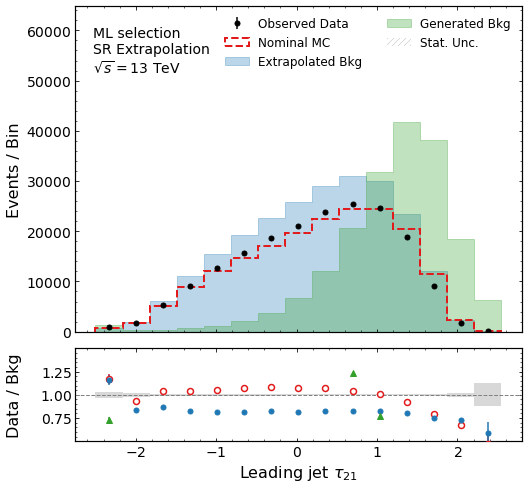

Metrics for ljet1_tau32 Extrapolation (Global Combined Model):
  Nominal      -> chi2/ndf: 1592.40/14 (p=0.0000) | Norm W1: 0.0910
  Extrapolated -> chi2/ndf: 3824.11/14 (p=0.0000) | Norm W1: 0.0243
  Generated    -> chi2/ndf: 90789.63/14 (p=0.0000) | Norm W1: 1.2443
------------------------------------------------------------


/tmp/ipykernel_48362/38619054.py:276: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved extrapolation plot: Extrapolation_Plots/SR_ML_ljet1_tau32.pdf
Saved SR Parquet events to AD_Events/


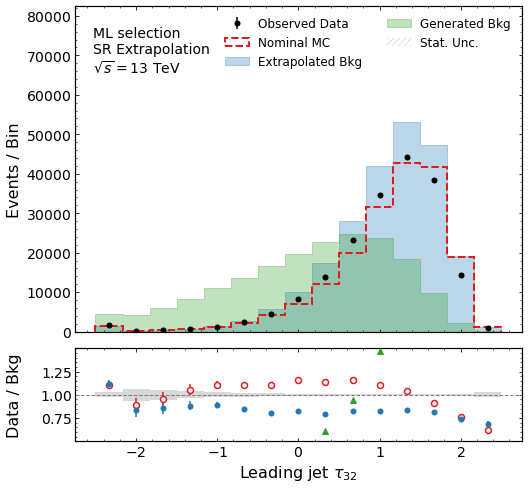

Metrics for ljet2_tau21 Extrapolation (Global Combined Model):
  Nominal      -> chi2/ndf: 849.98/14 (p=0.0000) | Norm W1: 0.0551
  Extrapolated -> chi2/ndf: 3673.94/14 (p=0.0000) | Norm W1: 0.0156
  Generated    -> chi2/ndf: 43317.99/14 (p=0.0000) | Norm W1: 0.5876
------------------------------------------------------------


/tmp/ipykernel_48362/38619054.py:276: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved extrapolation plot: Extrapolation_Plots/SR_ML_ljet2_tau21.pdf
Saved SR Parquet events to AD_Events/


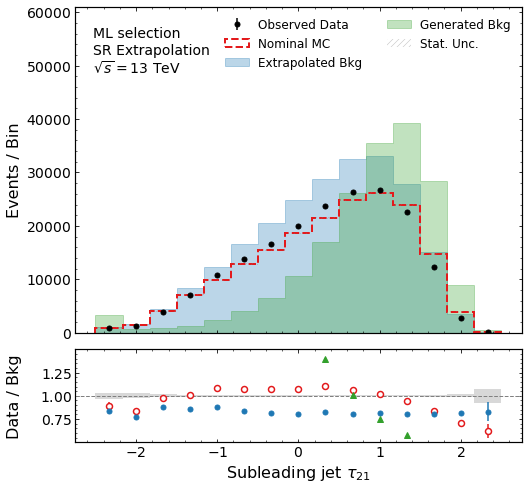

Metrics for ljet2_tau32 Extrapolation (Global Combined Model):
  Nominal      -> chi2/ndf: 1366.81/14 (p=0.0000) | Norm W1: 0.0773
  Extrapolated -> chi2/ndf: 3712.62/14 (p=0.0000) | Norm W1: 0.0265
  Generated    -> chi2/ndf: 366578.68/14 (p=0.0000) | Norm W1: 4.6477
------------------------------------------------------------


/tmp/ipykernel_48362/38619054.py:276: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)


Saved extrapolation plot: Extrapolation_Plots/SR_ML_ljet2_tau32.pdf
Saved SR Parquet events to AD_Events/


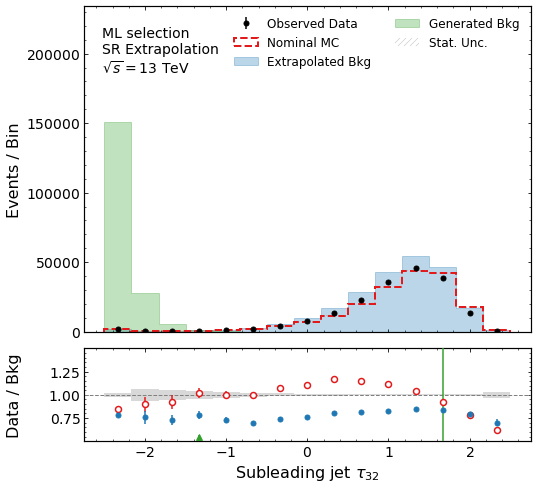


🎉 Extrapolation and Plotting phase complete! Check the 'SR_Extrapolation_Plots' folder.


In [9]:
import os
import sys
import torch
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy.stats import chi2 as chi2_stat
from scipy.stats import wasserstein_distance

target_region = "SR_clean"         

plot_dir = "SR_Extrapolation_Plots"
os.makedirs(plot_dir, exist_ok=True)

device = torch.device("cuda" if False else "cpu")
print(f"Using device: {device}")

# Variables to plot/evaluate
features_to_evaluate = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# Generative Model Setup (Specify which are context and which are generated)
context_vars = ['met_recalc_pt', 'ht'] 
features_to_generate = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

# ---------------------------------------------------------------------
# SELECT YOUR EXTRAPOLATION MODE (1, 2, or 3)
# ---------------------------------------------------------------------
EXTRAPOLATION_MODE = 2
GENERATE_SYNTHETIC = True # Toggle Generation on/off

N_ENSEMBLES = 1
DENSITY_PLOT = False

# Process Mapping for Mode 3
PROCESS_MAPPING = {
    'Wjets': 'CR1L',
    'ttbar': 'CR1L1B',
    'Single_top': 'CR1L1B',
    'Zjets': 'CR2L',
    'Multijet': 'CR0L',
    'Diboson': 'CR0L'
}

# =====================================================================
# 2. HELPER & GENERATOR FUNCTIONS
# =====================================================================
def regularize_weights(weights, sigma=3.0):
    """Caps extreme weight hallucinations at 3-sigma above the mean."""
    if len(weights) == 0: return weights
    mean_w = np.mean(weights)
    std_w = np.std(weights)
    upper_bound = mean_w + (sigma * std_w)
    return np.clip(weights, a_min=0, a_max=upper_bound)

def run_ensemble_inference(model_prefix, n_ensembles, x_data):
    """Loads ensemble models, averages probabilities, and returns ML weights."""
    if x_data.shape[0] == 0: return np.array([])
        
    accumulated_probs = np.zeros((x_data.shape[0], 1))
    successful_models = 0
    
    for i in range(n_ensembles):
        model_file = os.path.join(model_path, f"{model_prefix}_ens{i}.pt")
        try:
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            w_prob = model.evaluation(x_data)
            accumulated_probs += w_prob
            successful_models += 1
        except Exception as e:
            print(f"    [!] Failed to load {model_file}: {e}")
            
    if successful_models == 0:
        raise RuntimeError(f"No models found for prefix: {model_prefix}")
        
    avg_prob = accumulated_probs / successful_models
    avg_prob = np.clip(avg_prob, 1e-7, 1.0 - 1e-7)
    w_ml = (avg_prob / (1 - avg_prob)).flatten()
    
    return regularize_weights(w_ml, sigma=3.0)

def plot_sr_extrapolation(mode_label: str, df_mc: pl.DataFrame, df_gen: pl.DataFrame, df_data: pl.DataFrame, feature: str, force_log: bool = False):
    """
    Plots Extrapolated Background vs Generated Background vs Observed Data in the Signal Region.
    Styled to match ATLAS-like data/MC comparisons with stat bands and dynamic bounds.
    """
    plt.rcParams.update({
        'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 12, 'lines.linewidth': 1.5, 'xtick.direction': 'in', 'ytick.direction': 'in',
        'xtick.top': True, 'ytick.right': True, 'axes.formatter.use_mathtext': True, 'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]', 'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]', 'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]', 'ljet1_tau21': r'Leading jet $\tau_{21}$', 'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$', 'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }
    
    log_variables = ['ht', 'met_recalc_pt', 'met', 'mjj']
    use_log = force_log or any(log_var in feature.lower() for log_var in log_variables)
    
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    
    gen_arr = df_gen.get_column(feature).drop_nulls().to_numpy() if df_gen is not None and feature in df_gen.columns else np.array([])
    
    if len(data_arr) == 0:
        print(f"Skipping {feature} - No valid observed data.")
        return
        
    # Weights
    base_weight_col = "final_weight" 
    raw_weights = df_mc.get_column(base_weight_col).to_numpy()
    extrapolated_weights = df_mc.get_column("extrapolated_SR_weight").to_numpy()
    gen_weights = df_gen.get_column("weight").to_numpy() if df_gen is not None else np.array([])
    
    # Setup Figure (Updated to 8x8)
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Dynamic binning
    arrays_to_concat = [data_arr, mc_arr]
    if len(gen_arr) > 0: arrays_to_concat.append(gen_arr)
    combined_arr = np.concatenate(arrays_to_concat)
    bins = np.histogram_bin_edges(combined_arr, bins=15)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    # --- MAIN PANEL ---
    # Nominal MC (Red Step Line)
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights)
    sumw2_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights**2)
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights, histtype='step', 
                color='#e31a1c', linewidth=2, linestyle='--', label='Nominal MC')
                
    # Plot Nominal MC Statistical Uncertainty Band
    mc_err = np.sqrt(sumw2_raw)
    ax_main.bar(bin_centers, 2 * mc_err, bottom=counts_mc_raw - mc_err, width=bin_widths,
                color='none', edgecolor='gray', hatch='////', linewidth=0,
                alpha=0.5, zorder=5, label='Stat. Unc.')
    
    # Extrapolated Background (Blue Filled)
    counts_mc_extrap, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights)
    sumw2_extrap, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights**2)
    ax_main.hist(mc_arr, bins=bins, weights=extrapolated_weights, histtype='stepfilled', 
                color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label='Extrapolated Bkg')

    # Generated Background (Green Filled)
    counts_gen = np.zeros_like(counts_mc_raw)
    sumw2_gen = np.zeros_like(counts_mc_raw)
    if len(gen_arr) > 0:
        counts_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights)
        sumw2_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights**2)
        ax_main.hist(gen_arr, bins=bins, weights=gen_weights, histtype='stepfilled', 
                    color='#33a02c', alpha=0.3, edgecolor='#33a02c', label='Generated Bkg')

    # Target Data (Black Points)
    counts_data, _ = np.histogram(data_arr, bins=bins)
    data_errors = np.sqrt(counts_data)
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, 
                    fmt='ko', label='Observed Data', zorder=10, capsize=0, markersize=5)
    
    # --- METRICS CALCULATION ---
    std_data = np.std(data_arr) if len(data_arr) > 0 else 1.0
    c_mc_raw_clean = np.clip(counts_mc_raw, 0, None)
    c_mc_extrap_clean = np.clip(counts_mc_extrap, 0, None)
    c_gen_clean = np.clip(counts_gen, 0, None)
    
    w1_nom = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=c_mc_raw_clean) / std_data
    w1_extrap = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=c_mc_extrap_clean) / std_data
    w1_gen = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=c_gen_clean) / std_data if len(gen_arr) > 0 else 0

    def get_chi2_pval(c_data, c_mc, s2_mc):
        mask = (c_data > 0) | (c_mc > 0)
        tot_var = c_data[mask] + s2_mc[mask]
        valid = tot_var > 0
        chi2_val = np.sum((c_data[mask][valid] - c_mc[mask][valid])**2 / tot_var[valid])
        ndf = np.sum(valid) - 1 
        if ndf < 1: ndf = 1
        return chi2_val, ndf, chi2_stat.sf(chi2_val, ndf)

    chi2_nom, ndf_nom, p_nom = get_chi2_pval(counts_data, counts_mc_raw, sumw2_raw)
    chi2_extrap, ndf_extrap, p_extrap = get_chi2_pval(counts_data, counts_mc_extrap, sumw2_extrap)
    chi2_gen, ndf_gen, p_gen = get_chi2_pval(counts_data, counts_gen, sumw2_gen) if len(gen_arr) > 0 else (0,1,1)

    print(f"Metrics for {feature} Extrapolation ({mode_label}):")
    print(f"  Nominal      -> chi2/ndf: {chi2_nom:.2f}/{ndf_nom} (p={p_nom:.4f}) | Norm W1: {w1_nom:.4f}")
    print(f"  Extrapolated -> chi2/ndf: {chi2_extrap:.2f}/{ndf_extrap} (p={p_extrap:.4f}) | Norm W1: {w1_extrap:.4f}")
    if len(gen_arr) > 0:
        print(f"  Generated    -> chi2/ndf: {chi2_gen:.2f}/{ndf_gen} (p={p_gen:.4f}) | Norm W1: {w1_gen:.4f}")
    print("-" * 60)

    # --- DYNAMIC Y-AXIS SCALING ---
    max_mc = max(np.max(counts_mc_raw + mc_err), np.max(counts_mc_extrap), np.max(counts_gen) if len(counts_gen)>0 else 0)
    y_max = max(np.max(counts_data) + np.max(data_errors), max_mc)
    
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, y_max * 1000) # Updated matching multiplier
    else:
        ax_main.set_ylim(0, y_max * 1.55) # Updated matching multiplier
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    textstr = f"{selection} selection\n" + "SR Extrapolation\n" + r"$\sqrt{s} = 13$ TeV"
    ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                
    # Custom Legend Formatting
    handles, loc_labels = ax_main.get_legend_handles_labels()
    if "Observed Data" in loc_labels:
        idx = loc_labels.index("Observed Data")
        handles.insert(0, handles.pop(idx))
        loc_labels.insert(0, loc_labels.pop(idx))
    ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2) # Updated to ncol=2
    
    # --- RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        # Ratios
        ratio_raw = counts_data / counts_mc_raw
        ratio_extrap = counts_data / counts_mc_extrap
        ratio_gen = counts_data / counts_gen
        
        # Error Propagation (Data / Pred)
        rel_err_data = np.where(counts_data > 0, data_errors / counts_data, 0)
        
        # Fractional Nominal MC Error
        rel_err_raw = np.where(counts_mc_raw > 0, np.sqrt(sumw2_raw) / counts_mc_raw, 0)
        ratio_raw_err = np.abs(ratio_raw) * np.sqrt(rel_err_data**2 + rel_err_raw**2)
        
        rel_err_extrap = np.where(counts_mc_extrap > 0, np.sqrt(sumw2_extrap) / counts_mc_extrap, 0)
        ratio_extrap_err = np.abs(ratio_extrap) * np.sqrt(rel_err_data**2 + rel_err_extrap**2)
        
        rel_err_gen = np.where(counts_gen > 0, np.sqrt(sumw2_gen) / counts_gen, 0)
        ratio_gen_err = np.abs(ratio_gen) * np.sqrt(rel_err_data**2 + rel_err_gen**2)

        # Mask invalid values
        ratio_raw = np.where(counts_mc_raw > 0, ratio_raw, np.nan)
        ratio_extrap = np.where(counts_mc_extrap > 0, ratio_extrap, np.nan)
        ratio_gen = np.where(counts_gen > 0, ratio_gen, np.nan)

    # Plot Nominal MC Stat Uncertainty band around 1.0 in ratio panel
    ax_ratio.bar(bin_centers, 2 * rel_err_raw, bottom=1.0 - rel_err_raw, width=bin_widths,
                color='gray', hatch='////', edgecolor='none', alpha=0.3, zorder=1)

    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, zorder=2)
    
    # Plot Ratios
    ax_ratio.errorbar(bin_centers, ratio_raw, yerr=ratio_raw_err, fmt='o', 
                    color='#e31a1c', markerfacecolor='white', markeredgewidth=1.5, capsize=0, markersize=6, zorder=10)
    ax_ratio.errorbar(bin_centers, ratio_extrap, yerr=ratio_extrap_err, fmt='o', 
                    color='#1f78b4', capsize=0, markersize=5, zorder=10)
    if len(gen_arr) > 0:
        ax_ratio.errorbar(bin_centers, ratio_gen, yerr=ratio_gen_err, fmt='^', 
                        color='#33a02c', capsize=0, markersize=6, zorder=10)
    
    ax_ratio.set_xlabel(pretty_labels.get(feature, feature))
    ax_ratio.set_ylabel("Data / Bkg")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_yticks([0.75, 1.0, 1.25])
    
    ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=3)
    
    fig.align_ylabels((ax_main, ax_ratio))
    
    # Define plot_dir if not globally defined or pass it as an argument
    plot_dir = "Extrapolation_Plots"
    save_name = f"{plot_dir}/SR_{selection}_{feature}.pdf"
    
    plt.savefig(save_name, bbox_inches='tight', format='pdf') # Uncomment when directory is set up
    # --- SAVE EVENTS TO PARQUET ---
    events_dir = "AD_Events"
    os.makedirs(events_dir, exist_ok=True)
    
    # Save Data and MC (MC already contains both nominal and extrapolated weights)
    df_mc.write_parquet(f"{events_dir}/SR_events_mc_{selection}.parquet")
    df_data.write_parquet(f"{events_dir}/SR_events_data_{selection}.parquet")
    
    # Save Generated events only if they exist
    if df_gen is not None and len(df_gen) > 0:
        df_gen.write_parquet(f"{events_dir}/SR_events_gen_{selection}.parquet")
        
    print(f"Saved extrapolation plot: {save_name}")
    print(f"Saved SR Parquet events to {events_dir}/")
    
    plt.show()
    plt.close(fig)
# =====================================================================
# 4. LOAD DATASETS
# =====================================================================
print(f"\nLoading scaled Signal Region datasets ({target_region})...")
mc_sr_path = f"{dataset_path}/MC_{target_region}.parquet"
data_sr_path = f"{dataset_path}/DATA_{target_region}.parquet"

try:
    df_mc_sr = pl.read_parquet(mc_sr_path).to_pandas()
    df_data_sr = pl.read_parquet(data_sr_path)
    x_sr_mc = df_mc_sr[features_to_evaluate].values
    print(f"Loaded {df_mc_sr.shape[0]} MC events and {df_data_sr.height} Data events.")
except FileNotFoundError as e:
    print(f"Error: {e}")
    sys.exit(1)

weight_col = 'final_weight'

# =====================================================================
# 5. EXTRAPOLATION LOGIC
# =====================================================================
print("\n" + "="*70)
print(f" 🚀 INITIATING SR EXTRAPOLATION & PLOTTING (MODE {EXTRAPOLATION_MODE})")
print("="*70)

mode_label = f"Mode {EXTRAPOLATION_MODE}"

if EXTRAPOLATION_MODE == 1:
    print("Mode 1: Combining (multiplying) weights from all separate CR models.")
    regions = ["CR1L", "CR1L1B", "CR2L", "CR0L"]
    df_mc_sr['ml_extrapolation_weight'] = 1.0
    
    for region in regions:
        print(f" -> Applying corrections from {region}...")
        try:
            ml_weights = run_ensemble_inference(f"reweight_{region}", N_ENSEMBLES, x_sr_mc)
            df_mc_sr['ml_extrapolation_weight'] *= ml_weights 
        except RuntimeError as e:
            print(f"    [Skipping] {region}: {e}")
            
    df_mc_sr['ml_extrapolation_weight'] = regularize_weights(df_mc_sr['ml_extrapolation_weight'].values, sigma=3.0)
    mode_label = "Multiplied CRs"

elif EXTRAPOLATION_MODE == 2:
    print("Mode 2: Extrapolating using the single 'Combined_CRs' model.")
    try:
        ml_weights = run_ensemble_inference("reweight_Combined_CRs", N_ENSEMBLES, x_sr_mc)
        df_mc_sr['ml_extrapolation_weight'] = ml_weights
        mode_label = "Global Combined Model"
    except RuntimeError as e:
        print(f"Failed to run Combined model: {e}")
        sys.exit(1)

elif EXTRAPOLATION_MODE == 3:
    print("Mode 3: Process-Specific Component Extrapolation.")
    df_mc_sr['ml_extrapolation_weight'] = 1.0
    unique_processes = df_mc_sr['mc_process'].unique()
    
    for proc in unique_processes:
        target_cr = PROCESS_MAPPING.get(proc, 'CR0L')
        print(f" -> Process: {proc:<12} | Assigned Model: {target_cr}")
        
        mask = df_mc_sr['mc_process'] == proc
        x_proc = df_mc_sr.loc[mask, features_to_evaluate].values
        
        if x_proc.shape[0] > 0:
            try:
                ml_weights = run_ensemble_inference(f"reweight_{target_cr}", N_ENSEMBLES, x_proc)
                df_mc_sr.loc[mask, 'ml_extrapolation_weight'] = ml_weights
            except RuntimeError as e:
                print(f"    [!] Failed to evaluate {proc}: {e}")
                
    mode_label = "Process-Mapped"

# =====================================================================
# 6. GENERATION LOGIC
# =====================================================================
df_gen_sr_polars = None
if GENERATE_SYNTHETIC:
    print("\n" + "-"*70)
    print(" 🧬 GENERATING SYNTHETIC BACKGROUND FROM SR DATA")
    print("-"*70)
    
    # Typically, you use the global Combined_CRs model for SR generation.
    gen_model_prefix = "generate_Combined_CRs" 
    
    try:
        model_file = os.path.join(model_path, f"{gen_model_prefix}_ens0.pt")

        print(model_file)
        model = torch.load(model_file, map_location=device, weights_only=False)
        model.to(device)
        # df_data_sr_pd = df_data_sr.to_pandas()
        df_data_sr_pd = df_mc_sr
        df_gen_pd = generate_synthetic_data(
            model = model, 
            df_target_pd=df_data_sr_pd, 
            features=features_to_generate, 
            contexts=context_vars
        )
        df_gen_sr_polars = pl.from_pandas(df_gen_pd)
        print(f"✅ Generated synthetic features for {df_gen_pd.shape[0]} events.")
    except Exception as e:
        print(f"⚠️ Failed to generate synthetic data: {e}")
        GENERATE_SYNTHETIC = False

# =====================================================================
# 7. CALCULATE FINAL WEIGHTS, SAVE, AND PLOT
# =====================================================================
print("\nFinalizing datasets and generating plots...")

# Calculate the final physics weight
df_mc_sr['extrapolated_SR_weight'] = df_mc_sr[weight_col] * df_mc_sr['ml_extrapolation_weight']

# Convert back to Polars for saving and plotting
df_mc_sr_polars = pl.from_pandas(df_mc_sr)

# Setup output directory
output_dir = os.path.join(dataset_path, "SR_Extrapolations")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"MC_{target_region}_extrapolated_Mode{EXTRAPOLATION_MODE}.parquet")

# Save as Parquet
df_mc_sr_polars.write_parquet(output_path)
print(f"✅ Extrapolated Dataset Saved: {output_path}")

# Generate Plots
print(f"\nGenerating SR inspection plots for Mode {EXTRAPOLATION_MODE}...")
for feature in features_to_evaluate:
    plot_sr_extrapolation(mode_label, df_mc_sr_polars, df_gen_sr_polars, df_data_sr, feature)

print("\n🎉 Extrapolation and Plotting phase complete! Check the 'SR_Extrapolation_Plots' folder.")